# Detección de defectos de calidad en piezas manufacturadas con YOLO


## 1. Instalación de dependencias

In [ ]:
%pip install -q kagglehub ultralytics tqdm opencv-python-headless matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.4 MB/s eta 0:00:00


## 2. Imports y configuración global

In [ ]:
from __future__ import annotations
from pathlib import Path
import os
import random
import shutil
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm.auto import tqdm
from ultralytics import YOLO
import kagglehub

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# ── Parámetros principales ────────────────────────────────────────────────────
# Categoría de MVTec-AD a utilizar.
# Opciones: bottle, cable, capsule, carpet, grid, hazelnut, leather,
#           metal_nut, pill, screw, tile, toothbrush, transistor, wood, zipper
CATEGORY = "cable"

# Modelo base YOLO para clasificación
# yolo11n-cls (nano) = más rápido | yolo11s-cls / yolo11m-cls = más preciso
BASE_MODEL = "yolo11n-cls.pt"

# Carpeta de salida del dataset reformateado para YOLO
OUTPUT_ROOT = Path.cwd() / f"mvtec_{CATEGORY}_yolo_cls"

# Nombre del experimento
RUN_NAME   = f"mvtec_{CATEGORY}_cls"
TRAIN_NAME = "yolo11_ft"

# Proporciones de split sobre las imágenes de entrenamiento 'good'
TRAIN_RATIO = 0.85   # 85% → train, 15% → val

# Fracción de imágenes defectuosas usada en train/val (el resto queda en test)
DEFECT_TRAIN_FRACTION = 0.70

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# ── Dispositivo ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    ULTRA_DEVICE = 0
    print("GPU disponible:", torch.cuda.get_device_name(0))
else:
    ULTRA_DEVICE = "cpu"
    print("Usando CPU (se recomienda GPU)")

print(f"Categoría seleccionada : {CATEGORY}")
print(f"Modelo base            : {BASE_MODEL}")
print(f"Carpeta de salida      : {OUTPUT_ROOT}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU disponible: Tesla T4
Categoría seleccionada : cable
Modelo base            : yolo11n-cls.pt
Carpeta de salida      : /content/mvtec_cable_yolo_cls


## 3. Descarga del dataset MVTec-AD

In [ ]:
# Mismo dataset que la libreta ResNET50 (ipythonx/mvtec-ad)
# kagglehub lo descarga y cachea automáticamente.
mvtec_path = Path(kagglehub.dataset_download("ipythonx/mvtec-ad"))
print("Ruta del dataset:", mvtec_path)
print("Categorías disponibles:", sorted(os.listdir(mvtec_path)))

100%|██████████| 4.91G/4.91G [02:18<00:00, 38.0MB/s]

Extracting files...


Ruta del dataset: /root/.cache/kagglehub/datasets/ipythonx/mvtec-ad/versions/2
Categorías disponibles: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'license.txt', 'metal_nut', 'pill', 'readme.txt', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


## 4. Exploración de la categoría seleccionada

In [ ]:
category_path = mvtec_path / CATEGORY
assert category_path.exists(), f"No se encontró la categoría '{CATEGORY}' en {mvtec_path}"

train_good_dir = category_path / "train" / "good"
test_dir       = category_path / "test"

# Imágenes 'good' de entrenamiento
train_good_imgs = [p for p in train_good_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

# Imágenes de test: 'good' vs. todas las carpetas de defecto
test_classes = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
print(f"Subcarpetas en test: {test_classes}")

test_good_imgs   = []
test_defect_imgs = []
for cls_dir in test_dir.iterdir():
    if not cls_dir.is_dir():
        continue
    imgs = [p for p in cls_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    if cls_dir.name == "good":
        test_good_imgs.extend(imgs)
    else:
        test_defect_imgs.extend(imgs)

print(f"\nCategoría: {CATEGORY}")
print(f"  Train → good     : {len(train_good_imgs)} imágenes")
print(f"  Test  → good     : {len(test_good_imgs)} imágenes")
print(f"  Test  → defecto  : {len(test_defect_imgs)} imágenes ({len(test_classes)-1} tipos)")

Subcarpetas en test: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']

Categoría: cable
  Train → good     : 224 imágenes
  Test  → good     : 58 imágenes
  Test  → defecto  : 92 imágenes (8 tipos)


## 5. Conversión al formato de carpetas YOLO

YOLO para clasificación espera:
```
dataset/
  train/
    good/      ← imágenes sin defecto
    defect/    ← imágenes con defecto
  val/
    good/
    defect/
  test/
    good/
    defect/
```

**Estrategia de split:**
- `train/good` y `val/good` → del split `train/good` de MVTec (85% / 15%).
- `train/defect` y `val/defect` → 70% de las imágenes defectuosas del test MVTec.
- `test/` → las imágenes 'good' del test MVTec + el 30% restante de defectos (set de evaluación limpio).

In [ ]:
def split_list(items: list, ratio_a: float, seed: int = 42):
    """Divide una lista aleatoriamente: ratio_a para A, el resto para B."""
    items = items.copy()
    random.Random(seed).shuffle(items)
    n_a = int(len(items) * ratio_a)
    return items[:n_a], items[n_a:]


def build_yolo_dataset(
    train_good_imgs: list[Path],
    test_good_imgs: list[Path],
    test_defect_imgs: list[Path],
    output_root: Path,
    train_ratio: float = 0.85,
    defect_train_fraction: float = 0.70,
    seed: int = 42,
):
    # Limpiar y recrear carpetas
    if output_root.exists():
        shutil.rmtree(output_root)
    for split in ["train", "val", "test"]:
        for cls in ["good", "defect"]:
            (output_root / split / cls).mkdir(parents=True, exist_ok=True)

    # Good: split train/val desde las imágenes 'good' del train de MVTec
    train_good, val_good = split_list(train_good_imgs, train_ratio, seed)

    # Defect: parte para entrenamiento (train+val), parte para test final
    defect_trainval, defect_test = split_list(test_defect_imgs, defect_train_fraction, seed)
    train_defect, val_defect     = split_list(defect_trainval,  train_ratio, seed)

    assignments = {
        ("train", "good")   : train_good,
        ("train", "defect") : train_defect,
        ("val",   "good")   : val_good,
        ("val",   "defect") : val_defect,
        ("test",  "good")   : test_good_imgs,
        ("test",  "defect") : defect_test,
    }

    print("Distribución final del dataset:")
    for (split, cls), imgs in assignments.items():
        print(f"  {split:5s} / {cls:6s} : {len(imgs):4d} imágenes")

    # Copiar/enlazar archivos
    jobs = []
    for (split, cls), imgs in assignments.items():
        dst_dir = output_root / split / cls
        for idx, src in enumerate(imgs):
            dst = dst_dir / f"{cls}_{idx:06d}{src.suffix.lower()}"
            jobs.append((src, dst))

    def link_or_copy(src_dst):
        src, dst = src_dst
        try:
            os.link(src, dst)
        except OSError:
            shutil.copy2(src, dst)

    print(f"\nCopiando {len(jobs)} archivos...")
    with ThreadPoolExecutor(max_workers=min(16, os.cpu_count() or 4)) as ex:
        list(tqdm(ex.map(link_or_copy, jobs), total=len(jobs), desc="Preparando dataset"))

    print(f"\nDataset listo en: {output_root}")
    return assignments


assignments = build_yolo_dataset(
    train_good_imgs       = train_good_imgs,
    test_good_imgs        = test_good_imgs,
    test_defect_imgs      = test_defect_imgs,
    output_root           = OUTPUT_ROOT,
    train_ratio           = TRAIN_RATIO,
    defect_train_fraction = DEFECT_TRAIN_FRACTION,
    seed                  = RANDOM_SEED,
)

Distribución final del dataset:
  train / good   :  190 imágenes
  train / defect :   54 imágenes
  val   / good   :   34 imágenes
  val   / defect :   10 imágenes
  test  / good   :   58 imágenes
  test  / defect :   28 imágenes

Copiando 374 archivos...


Preparando dataset:   0%|          | 0/374 [00:00<?, ?it/s]


Dataset listo en: /content/mvtec_cable_yolo_cls


## 6. Visualización de muestras del dataset

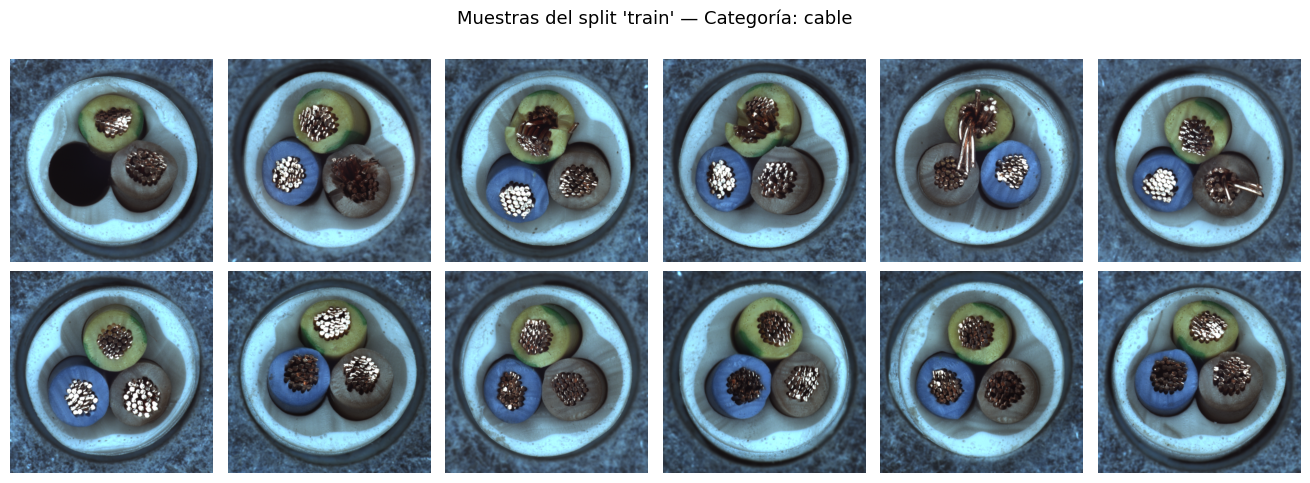

In [ ]:
def show_samples(dataset_root: Path, split: str = "train", n: int = 6):
    """Muestra n imágenes de ejemplo por clase del split indicado."""
    classes = sorted([d.name for d in (dataset_root / split).iterdir() if d.is_dir()])
    fig, axes = plt.subplots(len(classes), n, figsize=(n * 2.2, len(classes) * 2.5))
    if len(classes) == 1:
        axes = [axes]
    for row, cls in enumerate(classes):
        imgs = list((dataset_root / split / cls).glob("*"))[:n]
        for col in range(n):
            ax = axes[row][col]
            ax.axis("off")
            if col < len(imgs):
                img = cv2.cvtColor(cv2.imread(str(imgs[col])), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            if col == 0:
                ax.set_ylabel(cls, fontsize=11, fontweight="bold", rotation=90)
    plt.suptitle(f"Muestras del split '{split}' — Categoría: {CATEGORY}", fontsize=13)
    plt.tight_layout()
    plt.show()

show_samples(OUTPUT_ROOT, split="train", n=6)

## 7. Entrenamiento del modelo YOLO11

In [ ]:
assert OUTPUT_ROOT.exists(), f"No existe: {OUTPUT_ROOT}"

RUN_FULL_NAME = f"{RUN_NAME}_{TRAIN_NAME}"

model = YOLO(BASE_MODEL)

model.train(
    data    = str(OUTPUT_ROOT),   # Carpeta raíz con train/val/test
    task    = "classify",
    imgsz   = 224,                # 224 px es suficiente para fine-tuning rápido
    epochs  = 10,                 # Sube a 50-100 para mejores resultados
    batch   = 16,
    device  = ULTRA_DEVICE,
    project = "runs/classify",
    name    = RUN_FULL_NAME,
    pretrained    = True,
    seed          = RANDOM_SEED,
    deterministic = True,
    verbose  = True,
    workers  = 4,
    exist_ok = True,
    # Augmentaciones apropiadas para imágenes industriales
    flipud   = 0.5,
    fliplr   = 0.5,
    degrees  = 15,
    translate= 0.1,
    scale    = 0.3,
)

# Construct the primary expected path for best weights
best_weights = Path("runs/classify") / RUN_FULL_NAME / "weights" / "best.pt"

# Check if the file exists at the primary path
if not best_weights.exists():
    # If not found, try the common alternative nested path
    best_weights = Path("runs/classify/runs/classify") / RUN_FULL_NAME / "weights" / "best.pt"

# Assert that the best weights file now exists
assert best_weights.exists(), f"No se encontraron los pesos en las rutas esperadas: {best_weights}"
print("\nMejores pesos guardados en:", best_weights)


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mvtec_cable_yolo_cls, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mvtec_cable_cls_yolo11_ft, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## 8. Evaluación del modelo entrenado

In [ ]:
def metrics_to_dataframe(split_name: str, metrics) -> pd.DataFrame:
    return pd.DataFrame([{
        "split"   : split_name,
        "top1_acc": round(metrics.top1, 4),
        "top5_acc": round(metrics.top5, 4),
        "fitness" : round(metrics.fitness, 4),
    }])

# Ruta robusta a los mejores pesos
best_weights = Path("runs/classify") / RUN_FULL_NAME / "weights" / "best.pt"
if not best_weights.exists():
    best_weights = Path("runs/classify/runs/classify") / RUN_FULL_NAME / "weights" / "best.pt"
assert best_weights.exists(), f"No se encontraron los pesos: {best_weights}"

classifier_model = YOLO(str(best_weights))

val_metrics  = classifier_model.val(data=str(OUTPUT_ROOT), split="val",  imgsz=224, device=ULTRA_DEVICE)
test_metrics = classifier_model.val(data=str(OUTPUT_ROOT), split="test", imgsz=224, device=ULTRA_DEVICE)

metrics_df = pd.concat([
    metrics_to_dataframe("val",  val_metrics),
    metrics_to_dataframe("test", test_metrics),
], ignore_index=True)

print(f"\nResultados — Categoría: {CATEGORY}")
display(metrics_df)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/mvtec_cable_yolo_cls/train... found 244 images in 2 classes ✅ 
val: /content/mvtec_cable_yolo_cls/val... found 44 images in 2 classes ✅ 
test: /content/mvtec_cable_yolo_cls/test... found 86 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4333.9±948.5 MB/s, size: 1314.2 KB)
val: Scanning /content/mvtec_cable_yolo_cls/val... 44 images, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 13.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.1s
                   all      0.955          1
Speed: 0.8ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val3
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/mvtec_cable_yolo_cls/train... found 244 images in 2 

,split,top1_acc,top5_acc,fitness
0,val,0.9545,1.0,0.9773
1,test,0.9419,1.0,0.9709


## 9. Inferencia en imágenes individuales del test

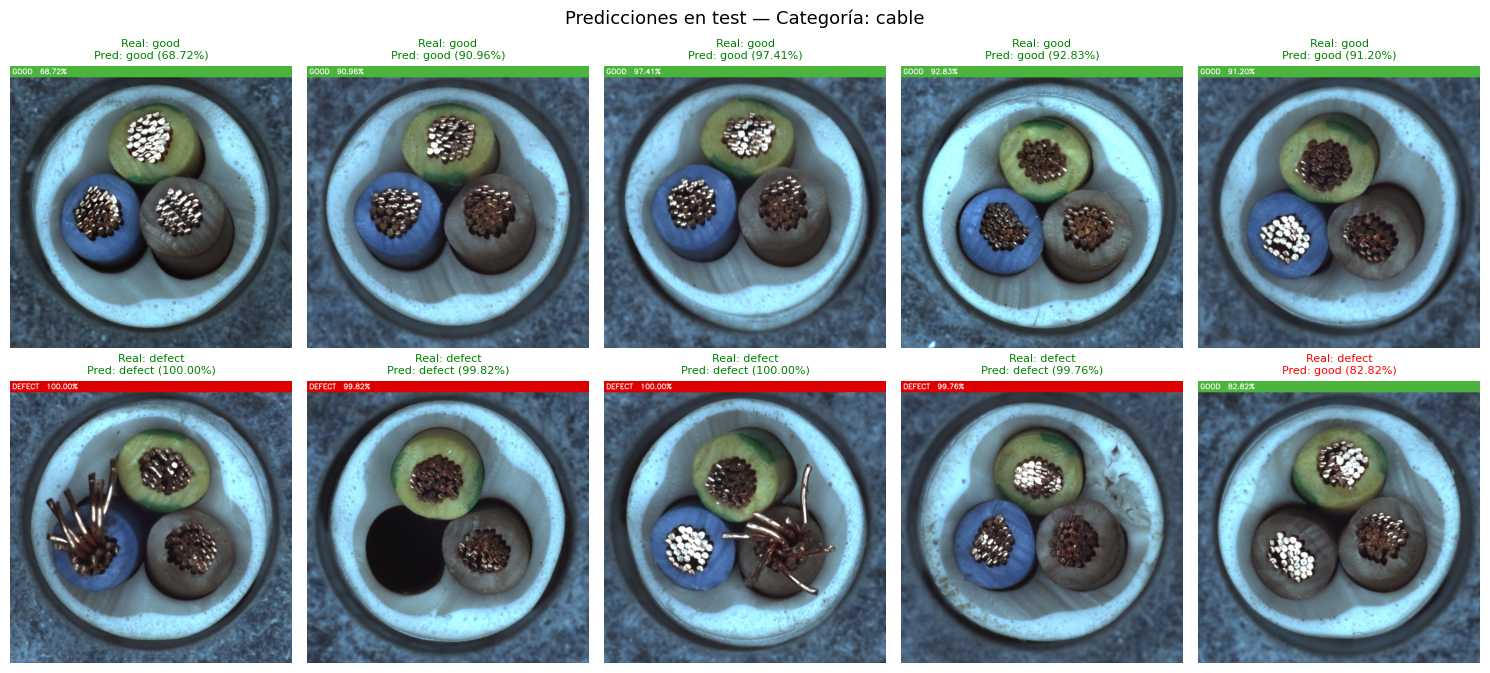

In [ ]:
def classify_image(image_path: Path | str, model: YOLO, imgsz: int = 224):
    """Clasifica una imagen como 'good' o 'defect' y devuelve la imagen anotada."""
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f"No se pudo leer: {image_path}")

    result    = model.predict(source=bgr, imgsz=imgsz, device=ULTRA_DEVICE, verbose=False)[0]
    top_idx   = int(result.probs.top1)
    label     = result.names[top_idx]
    conf      = float(result.probs.top1conf.item())

    # Anotación visual con barra de color
    color     = (60, 180, 75) if label == "good" else (0, 0, 220)   # verde / rojo
    annotated = bgr.copy()
    cv2.rectangle(annotated, (0, 0), (annotated.shape[1], 40), color, -1)
    cv2.putText(annotated, f"{label.upper()}  {conf:.2%}",
                (8, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 2)
    return annotated, label, conf


def show_test_predictions(dataset_root: Path, model: YOLO, n_per_class: int = 5):
    """Muestra predicciones aleatorias del test para ambas clases."""
    classes = ["good", "defect"]
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 3, len(classes) * 3.5))
    for row, cls in enumerate(classes):
        all_imgs = list((dataset_root / "test" / cls).glob("*"))
        samples  = random.sample(all_imgs, min(n_per_class, len(all_imgs)))
        for col, img_path in enumerate(samples):
            ax = axes[row][col]
            ax.axis("off")
            try:
                annotated, pred_label, pred_conf = classify_image(img_path, model)
                ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
                correct      = pred_label == cls
                title_color  = "green" if correct else "red"
                ax.set_title(f"Real: {cls}\nPred: {pred_label} ({pred_conf:.2%})",
                             fontsize=8, color=title_color)
            except Exception as e:
                ax.set_title(str(e), fontsize=7, color="gray")
    plt.suptitle(f"Predicciones en test — Categoría: {CATEGORY}", fontsize=13)
    plt.tight_layout()
    plt.show()


show_test_predictions(OUTPUT_ROOT, classifier_model, n_per_class=5)

## 10. Análisis de errores por tipo de defecto

In [ ]:
# Evalúa sobre TODAS las imágenes del test original de MVTec,
# desagregando resultados por tipo de defecto.

results_rows = []

for cls_dir in sorted(test_dir.iterdir()):
    if not cls_dir.is_dir():
        continue
    true_label = "good" if cls_dir.name == "good" else "defect"
    imgs = [p for p in cls_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

    for img_path in tqdm(imgs, desc=f"Evaluando: {cls_dir.name}", leave=False):
        try:
            _, pred_label, pred_conf = classify_image(img_path, classifier_model)
            results_rows.append({
                "defect_type" : cls_dir.name,
                "true_label"  : true_label,
                "pred_label"  : pred_label,
                "confidence"  : round(pred_conf, 4),
                "correct"     : (pred_label == true_label),
            })
        except Exception:
            pass

results_df = pd.DataFrame(results_rows)

# Tabla resumen por tipo de defecto
summary = (
    results_df
    .groupby("defect_type")
    .agg(
        total    = ("correct", "count"),
        correct  = ("correct", "sum"),
        accuracy = ("correct", "mean"),
        avg_conf = ("confidence", "mean"),
    )
    .reset_index()
    .sort_values("accuracy", ascending=False)
)
summary["accuracy"] = summary["accuracy"].map("{:.1%}".format)
summary["avg_conf"] = summary["avg_conf"].map("{:.3f}".format)

print(f"Accuracy por tipo de defecto — Categoría: {CATEGORY}")
display(summary)

overall_acc = results_df["correct"].mean()
print(f"\nAccuracy global sobre test MVTec original: {overall_acc:.2%}")

Evaluando: bent_wire:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluando: cable_swap:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluando: combined:   0%|          | 0/11 [00:00<?, ?it/s]

Evaluando: cut_inner_insulation:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluando: cut_outer_insulation:   0%|          | 0/10 [00:00<?, ?it/s]

...

Evaluando: missing_wire:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluando: poke_insulation:   0%|          | 0/10 [00:00<?, ?it/s]

Accuracy por tipo de defecto — Categoría: cable


,defect_type,total,correct,accuracy,avg_conf
0,bent_wire,13,13,100.0%,0.964
2,combined,11,11,100.0%,0.994
4,cut_outer_insulation,10,10,100.0%,0.910
6,missing_cable,12,12,100.0%,0.999
5,good,58,57,98.3%,0.894
3,cut_inner_insulation,14,13,92.9%,0.936
7,missing_wire,10,9,90.0%,0.963
8,poke_insulation,10,9,90.0%,0.933
1,cable_swap,12,5,41.7%,0.694



Accuracy global sobre test MVTec original: 92.67%
